In [1]:
import os
import json
import re
from pathlib import Path
from collections import Counter

import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

### Load R2Gen-preprocessed IU X-Ray
This notebook assumes the R2Gen-preprocessed IU X-Ray bundle is present at
`~/scratch/dl-project/data/iu-xray/iu_xray/`. If it isn't, follow
`docs/setup_iu_xray.md` first (steps 1-3 at minimum).

In [28]:

DATA_ROOT = Path.home() / "scratch" / "dl-project" / "data" / "iu-xray" / "iu_xray"
IMAGES_DIR = DATA_ROOT / "images"
ANNOTATION_PATH = DATA_ROOT / "annotation.json"

if not DATA_ROOT.is_dir():
    raise FileNotFoundError(
        f"IU X-Ray dataset not found at {DATA_ROOT}.\n"
        f"Please follow docs/setup_iu_xray.md first (steps 1-3 at minimum: "
        f"install gdown, download the Google Drive bundle, extract it)."
    )

if not ANNOTATION_PATH.exists():
    raise FileNotFoundError(
        f"annotation.json missing at {ANNOTATION_PATH}.\n"
        f"The R2Gen bundle extraction may have failed. "
        f"See docs/setup_iu_xray.md for how to re-download and extract."
    )
    
# assert DATA_ROOT.is_dir(), f"Dataset not found at {DATA_ROOT}. Run setup_iu_xray.md first."
# assert ANNOTATION_PATH.exists(), f"annotation.json missing at {ANNOTATION_PATH}"
print(f"Dataset root: {DATA_ROOT}")
print(f"annotation.json size: {ANNOTATION_PATH.stat().st_size:,} bytes")

BATCH_SIZE = 32

Dataset root: /home/hice1/ywang4185/scratch/dl-project/data/iu-xray/iu_xray
annotation.json size: 1,008,692 bytes


### Define Transformer

In [3]:

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),      # Models need consistent sizes
    transforms.ToTensor(),              # THIS converts PNG -> Tensor (Pixels 0 to 1)
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Standard scaling
])

# train_dataset = FlatDirectoryDataset(root_dir=images_path, transform=data_transforms)

# # 3. Create the Loader
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

### Load annotation.json
Load the R2Gen split/annotation file. This replaces the Kaggle CSV merge — the R2Gen bundle already has reports joined to their studies and split assignments baked in

In [10]:
with open(ANNOTATION_PATH) as f:
    annotation = json.load(f)

for split_name, entries in annotation.items():
    print(f"  {split_name}: {len(entries)} studies")

# Expected: train: 2069, val: 296, test: 590 (canonical R2Gen split)
# Schema of each entry:
#   id         -> study identifier, e.g. "CXR2384_IM-0942"
#   report     -> findings text (the R2Gen bundle uses findings, not impression)
#   image_path -> list of relative paths under images/, 1 to 3 views per study
#   split      -> "train" | "val" | "test"
print("\nsample entry:", annotation["train"][0])

  train: 2069 studies
  val: 296 studies
  test: 590 studies

sample entry: {'id': 'CXR2384_IM-0942', 'report': 'The heart size and pulmonary vascularity appear within normal limits. A large hiatal hernia is noted. The lungs are free of focal airspace disease. No pneumothorax or pleural effusion is seen. Degenerative changes are present in the spine.', 'image_path': ['CXR2384_IM-0942/0.png', 'CXR2384_IM-0942/1.png'], 'split': 'train'}


### Build a dict {filename: [report]} from R2Gen annotations
R2Gen stores one report per study, so each image from that study shares the same report.

In [11]:
# Create a dictionary of image filenames and their corresponding captions
data = {}
all_entries = annotation["train"] + annotation["val"] + annotation["test"]
for entry in all_entries:
    report = entry["report"]
    for rel_path in entry["image_path"]:
        # R2Gen paths look like "CXR2384_IM-0942/0.png"; we use the full
        # relative path as the filename key so multiple views of the same
        # study don't collide.
        filename = rel_path
        if filename not in data:
            data[filename] = []
        data[filename].append(report)

print(f"Built data dict with {len(data)} image entries.")
print(f"Sample: {list(data.items())[0]}")

Built data dict with 5910 image entries.
Sample: ('CXR2384_IM-0942/0.png', ['The heart size and pulmonary vascularity appear within normal limits. A large hiatal hernia is noted. The lungs are free of focal airspace disease. No pneumothorax or pleural effusion is seen. Degenerative changes are present in the spine.'])


### Clean up the report text
 by removing newlines and extra spaces

In [12]:
def cleanse_data(data):
    """
    Lowercase each report and normalize whitespace.
    """
    dict_2 = dict()
    for key, value in data.items():
        for line in value:
            if not isinstance(line, str):
                continue
            cleaned = " ".join(line.lower().split())  # lowercase + collapse whitespace
            if key not in dict_2:
                dict_2[key] = list()
            dict_2[key].append(cleaned)
    return dict_2

data2 = cleanse_data(data)
print(f"Cleansed {len(data2)} entries.")
print(f"Sample: {list(data2.items())[0]}")

Cleansed 5910 entries.
Sample: ('CXR2384_IM-0942/0.png', ['the heart size and pulmonary vascularity appear within normal limits. a large hiatal hernia is noted. the lungs are free of focal airspace disease. no pneumothorax or pleural effusion is seen. degenerative changes are present in the spine.'])


### Build set of all unique words

In [14]:
# convert the following into a vocabulary of words and calculate the total words

def vocabulary(data2):
    all_desc = set()
    for key in data2.keys():
        [all_desc.update(d.split()) for d in data2[key]]
    return all_desc

# summarize vocabulary
vocabulary_data = vocabulary(data2)
print(f"unique words before frequency filter: {len(vocabulary_data)}")

unique words before frequency filter: 2274


### Build dataframe
with 'split' column so downstream code can respect the R2Gen train/val/test assignments at study level.

In [15]:
import pandas as pd

# Map each filename to its R2Gen split assignment
filename_to_split = {}
for split_name in ("train", "val", "test"):
    for entry in annotation[split_name]:
        for rel_path in entry["image_path"]:
            filename_to_split[rel_path] = split_name

data_list = [
    (fname, findings[0], filename_to_split[fname])
    for fname, findings in data2.items()
]
df = pd.DataFrame(data_list, columns=["filename", "finding", "split"])

print(f"df shape: {df.shape}")
print(df["split"].value_counts())
print(df.head(3))


df shape: (5910, 3)
split
train    4138
test     1180
val       592
Name: count, dtype: int64
                filename                                            finding  \
0  CXR2384_IM-0942/0.png  the heart size and pulmonary vascularity appea...   
1  CXR2384_IM-0942/1.png  the heart size and pulmonary vascularity appea...   
2  CXR2926_IM-1328/0.png  cardiac and mediastinal contours are within no...   

   split  
0  train  
1  train  
2  train  


### Build the vocabulary of findings.

In [16]:
# Build the vocabulary of findings
from collections import Counter
import re

PAD_ID, BOS_ID, EOS_ID, UNK_ID = 0, 1, 2, 3
MIN_WORD_FREQ = 3

# 1. Basic Cleaning & Tokenization (Split by space)
def simple_tokenizer(text):
    text = text.lower()
    # text = re.sub(r"[[.,!?]]", "", text) # Remove punctuation
    text = re.sub(r"[.,!?]", "", text)
    return text.split()

# 2. Build the Vocab — using TRAINING SPLIT ONLY
train_df = df[df["split"] == "train"]
word_counts = Counter()
for finding in train_df["finding"]:
    word_counts.update(simple_tokenizer(finding))
  
# 3. Create the Map (Word -> Index)  
vocab = {
    "<PAD>": PAD_ID,
    "<BOS>": BOS_ID,
    "<EOS>": EOS_ID,
    "<UNK>": UNK_ID,
}
for word, count in sorted(word_counts.items(), key=lambda kv: (-kv[1], kv[0])):
    if count >= MIN_WORD_FREQ:
        vocab[word] = len(vocab)

# Reverse map for checking results later
inv_vocab = {v: k for k, v in vocab.items()}

print(f"train-split word types (pre-filter): {len(word_counts)}")
print(f"vocab size (incl. 4 special tokens): {len(vocab)}")

train-split word types (pre-filter): 1519
vocab size (incl. 4 special tokens): 984


### Establish Dataset Class

In [23]:
MAX_REPORT_LEN = 60  # max tokens including <BOS>/<EOS>

class XRayDataset(Dataset):
    def __init__(self, dataframe, img_dir, vocab, split=None, max_len=MAX_REPORT_LEN, transform=None):
        if split is not None:
            dataframe = dataframe[dataframe["split"] == split].reset_index(drop=True)
        self.df = dataframe
        self.img_dir = img_dir
        self.vocab = vocab
        self.max_len = max_len
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # --- Image Logic ---
        img_path = os.path.join(self.img_dir, row['filename'])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        
        # --- Text/LSTM Logic ---
        tokens = simple_tokenizer(row['finding'])
        # Convert words to IDs, use 1 (<UNK>) if word isn't in vocab
        token_ids = [self.vocab.get(t, UNK_ID) for t in tokens]
        
        # Wrap with <BOS>/<EOS> and truncate (ensure final token is <EOS>)
        token_ids = [BOS_ID] + token_ids + [EOS_ID]
        if len(token_ids) > self.max_len:
            token_ids = token_ids[: self.max_len - 1] + [EOS_ID]

        # Shifted input/target for teacher forcing
        input_tokens = token_ids[:-1]
        target_tokens = token_ids[1:]
        length = len(target_tokens)

        return {
            "image": image,
            "input_tokens": torch.tensor(input_tokens, dtype=torch.long),
            "target_tokens": torch.tensor(target_tokens, dtype=torch.long),
            "length": length,
            "image_id": row["filename"],  # e.g. "CXR2384_IM-0942/0.png" — unique per image
        }

def pad_collate(batch):
    """
    Collate into the interfaces.md §1 5-tuple:
      (images, input_tokens, target_tokens, lengths, image_ids)
    Sequences right-padded with PAD_ID.
    """
    images = torch.stack([b["image"] for b in batch], dim=0)
    lengths = torch.tensor([b["length"] for b in batch], dtype=torch.long)
    max_len = int(lengths.max().item())
    B = len(batch)

    input_tokens = torch.full((B, max_len), PAD_ID, dtype=torch.long)
    target_tokens = torch.full((B, max_len), PAD_ID, dtype=torch.long)
    for i, b in enumerate(batch):
        L = b["length"]
        input_tokens[i, :L] = b["input_tokens"]
        target_tokens[i, :L] = b["target_tokens"]

    image_ids = [b["image_id"] for b in batch]
    return images, input_tokens, target_tokens, lengths, image_ids

### Initialize datasets per split
and wrap them in dataloader

In [24]:
# Initialize with your vocab
train_dataset = XRayDataset(df, IMAGES_DIR, vocab, split="train",
                                max_len=MAX_REPORT_LEN, transform=data_transforms)
val_dataset   = XRayDataset(df, IMAGES_DIR, vocab, split="val",
                                max_len=MAX_REPORT_LEN, transform=data_transforms)
test_dataset  = XRayDataset(df, IMAGES_DIR, vocab, split="test",
                                max_len=MAX_REPORT_LEN, transform=data_transforms)


In [ ]:
# 3. Wrap them in DataLoaders
# BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, collate_fn=pad_collate)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, collate_fn=pad_collate)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, collate_fn=pad_collate)
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 4138, Val: 592, Test: 1180


### Sanity check: print some examples from the dataloader

In [26]:
batch = next(iter(train_loader))
images, input_tokens, target_tokens, lengths, image_ids = batch

print(f"Images shape: {images.shape}")               # expected: [B, 3, 224, 224]
print(f"Input tokens shape: {input_tokens.shape}")   # expected: [B, T]
print(f"Target tokens shape: {target_tokens.shape}") # expected: [B, T]
print(f"Lengths shape: {lengths.shape}")             # expected: [B]
print(f"Image IDs (first 3): {image_ids[:3]}")
print(f"Example input sequence: {input_tokens[0]}")
print(f"Example target sequence: {target_tokens[0]}")

Images shape: torch.Size([32, 3, 224, 224])
Input tokens shape: torch.Size([32, 59])
Target tokens shape: torch.Size([32, 59])
Lengths shape: torch.Size([32])
Image IDs (first 3): ['CXR3297_IM-1575/1.png', 'CXR167_IM-0441/0.png', 'CXR95_IM-2445/0.png']
Example input sequence: tensor([  1,   4,  17,   6,   8,  24,  19,   4,  40,   6,  41,  48, 274,  38,
          7,  68,   4,  18,   7,  99,  22,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0])
Example target sequence: tensor([  4,  17,   6,   8,  24,  19,   4,  40,   6,  41,  48, 274,  38,   7,
         68,   4,  18,   7,  99,  22,   2,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0])


### Visualize the sample

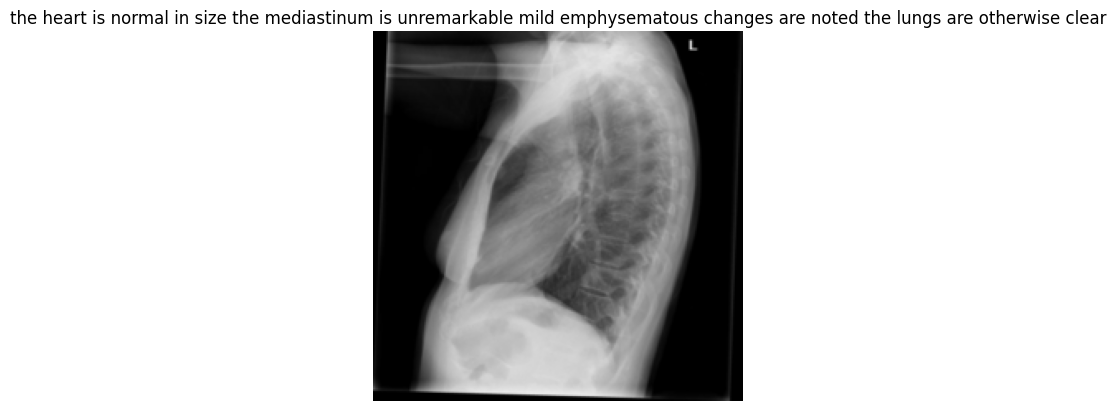

In [27]:
def tokens_to_string(tokens, inv_vocab):
    # Convert tensor to list, find words, and filter out <PAD>
    words = []
    for t in tokens:
        tid = int(t.item()) if hasattr(t, "item") else int(t)
        if tid in (PAD_ID, BOS_ID, EOS_ID):
            continue
        words.append(inv_vocab.get(tid, "<UNK>"))
    return " ".join(words)

import matplotlib.pyplot as plt
# Grab one sample from the training set
sample_img = images[0]
sample_target = target_tokens[0, : lengths[0]]

actual_text = tokens_to_string(sample_target, inv_vocab)

# Undo ImageNet normalization for display
# Convert the tensor back to a NumPy array for plotting
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
sample_img_np = (sample_img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


plt.imshow(sample_img_np)
plt.title(actual_text)
plt.axis('off')
plt.show()